# Задание по Python DA: analysis. Zahoruiko Anna

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose

from scipy import stats

In [3]:
with open("data.pickle", "rb") as f:
    df_calls, df_contacts, df_deals, df_spend = pickle.load(f)

print("Датафреймы успешно загружены")

Датафреймы успешно загружены


## 3. Анализ временных рядов
 #### 3.1. Проанализируйте тенденцию создания сделок с течением времени и их связь с звонками.

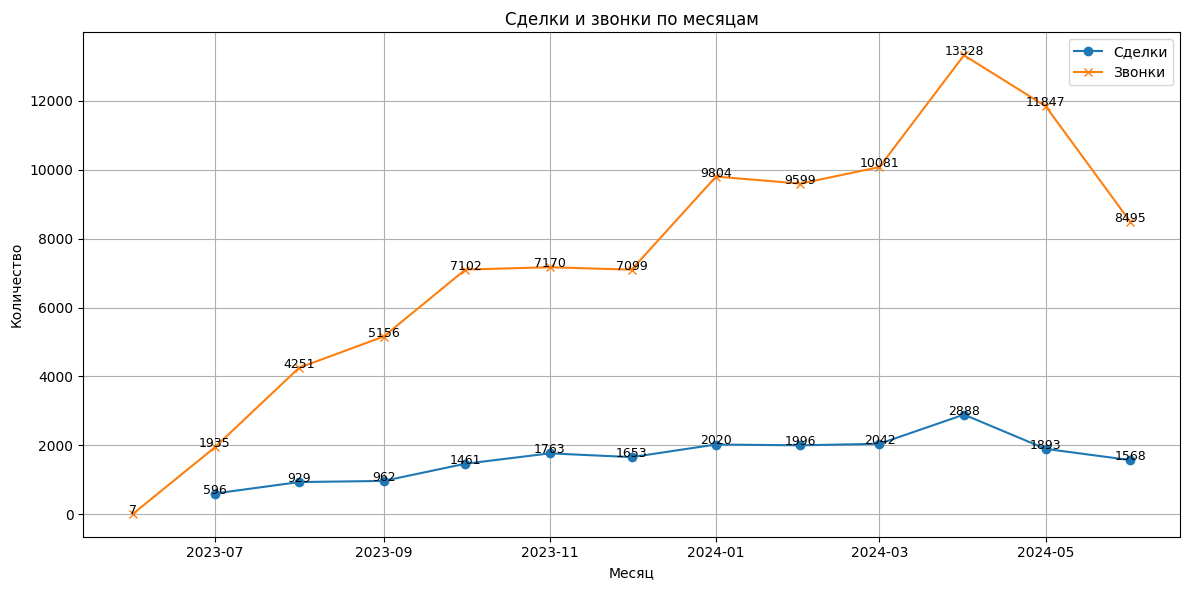

In [3]:
calls_monthly = (
    df_calls.groupby(df_calls['Call_Start_Time'].dt.to_period('M'))
         .size()
         .reset_index(name='Сalls_Сount')
         .rename(columns={'Call_Start_Time': 'month'}))            

calls_monthly['month'] = calls_monthly['month'].dt.to_timestamp()  
calls_monthly = calls_monthly.sort_values('month')                

deals_monthly = (
    df_deals.groupby(df_deals['Created_Time'].dt.to_period('M'))
         .size()
         .reset_index(name='Deals_Count')
         .rename(columns={'Created_Time': 'month'})
)

deals_monthly['month'] = deals_monthly['month'].dt.to_timestamp()   
deals_monthly = deals_monthly.sort_values('month')                 


plt.figure(figsize=(12,6))
plt.plot(deals_monthly['month'], deals_monthly['Deals_Count'], label='Сделки', marker='o')
plt.plot(calls_monthly['month'], calls_monthly['Сalls_Сount'], label='Звонки', marker='x')

# подписи над точками
for x, y in zip(deals_monthly['month'], deals_monthly['Deals_Count']):
    plt.text(x, y + 0.5, str(int(y)), ha='center', fontsize=9)
for x, y in zip(calls_monthly['month'], calls_monthly['Сalls_Сount']):
    plt.text(x, y + 0.5, str(int(y)), ha='center', fontsize=9)

plt.title('Сделки и звонки по месяцам')
plt.xlabel('Месяц'); plt.ylabel('Количество')
plt.legend(); plt.grid(True); plt.tight_layout()


**ВЫВОДЫ:**

Общая динамика
Наблюдается устойчивый рост как по количеству звонков, так и по количеству сделок в течение рассматриваемого периода.
Это может указывать на расширение активности отдела продаж и увеличение маркетинговых усилий.
    
Соотношение звонков и сделок
Звонков стабильно в несколько раз больше, чем сделок, что отражает естественную воронку продаж.
Однако разрыв между количеством звонков и количеством сделок сохраняется значительным, что указывает на необходимость анализа качества контактов и скриптов продаж.

Пики активности
Максимальное количество звонков зафиксировано в мартe 2024 года (13 228 звонков), при этом сделки также достигли локального максимума (2 888 сделок).
Это подтверждает прямую зависимость между активностью звонков и ростом числа сделок.

Снижение показателей
В мае 2024 года количество звонков снизилось до 8 495, что сопровождалось падением сделок до 1 568.
Такое параллельное снижение может указывать как на сезонность, так и на ограничение ресурсов команды.

Эффективность
Несмотря на рост активности, коэффициент конверсии звонков в сделки остаётся относительно стабильным и невысоким.
Это говорит о том, что для дальнейшего роста результативности необходимо не только увеличивать количество звонков, но и работать над качеством взаимодействия с клиентами.

#### Для выявления трендов и сезонных колебаний выполним структурный анализ временного ряда, агрегированного по двухнедельным промежуткам

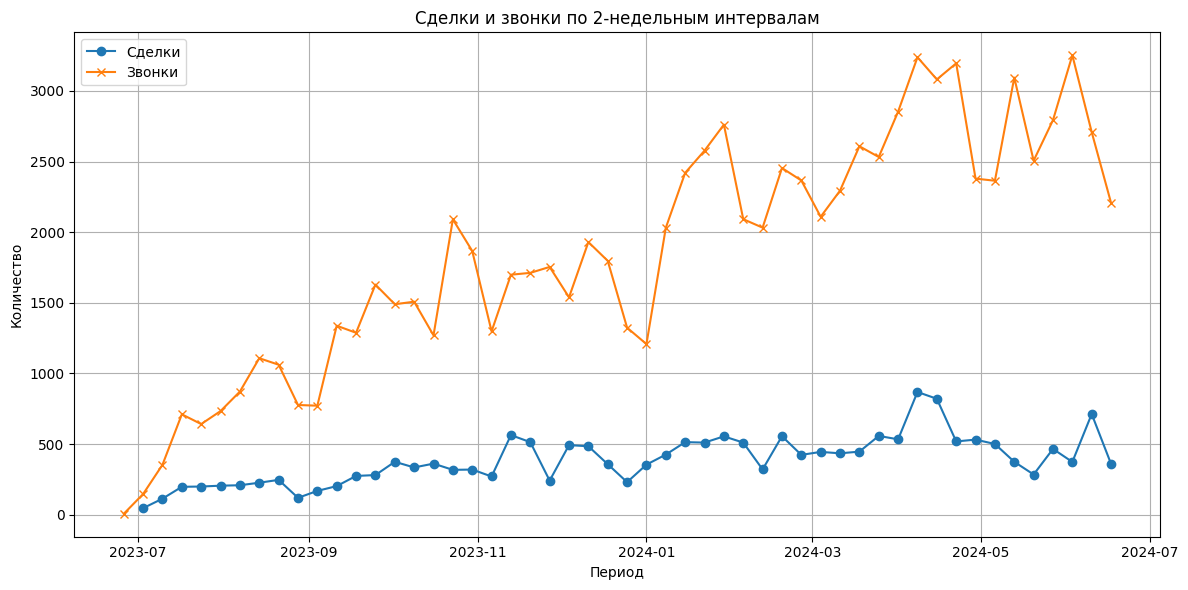

In [5]:
calls_2w = (
    df_calls.groupby(df_calls['Call_Start_Time'].dt.to_period('2W'))
         .size()
         .reset_index(name='Calls_Count')
         .rename(columns={'Call_Start_Time': 'period'})
)

calls_2w['period'] = calls_2w['period'].dt.to_timestamp()  
calls_2w = calls_2w.sort_values('period')                

deals_2w = (
    df_deals.groupby(df_deals['Created_Time'].dt.to_period('2W'))
         .size()
         .reset_index(name='Deals_Count')
         .rename(columns={'Created_Time': 'period'})
)

deals_2w['period'] = deals_2w['period'].dt.to_timestamp()   
deals_2w = deals_2w.sort_values('period')                 

plt.figure(figsize=(12,6))
plt.plot(deals_2w['period'], deals_2w['Deals_Count'], label='Сделки', marker='o')
plt.plot(calls_2w['period'], calls_2w['Calls_Count'], label='Звонки', marker='x')

plt.title('Сделки и звонки по 2-недельным интервалам')
plt.xlabel('Период')
plt.ylabel('Количество')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**ВЫВОДЫ по графику «Сделки и звонки по 2-недельным интервалам»:**

Общая динамика
Количество звонков и сделок демонстрирует общий восходящий тренд на протяжении всего анализируемого периода.
Это указывает на рост активности команды и расширение клиентской базы.

Звонки как драйвер сделок
Между динамикой звонков и сделок наблюдается прямая зависимость: увеличение звонков сопровождается ростом количества сделок, хотя амплитуда колебаний по звонкам выше.
Это подтверждает ключевую роль звонков как основного инструмента генерации сделок.

Колебания активности
График звонков имеет выраженные пики и спады каждые несколько недель, что может быть связано с планированием кампаний, сезонными факторами или внутренней организацией работы отдела продаж.
Сделки реагируют на эти изменения с более сглаженной динамикой, что типично для воронки продаж.

Рост к весне 2024 года
С марта по май 2024 года звонки достигают максимальных значений (свыше 3 000 за 2 недели).
Параллельно фиксируется и рост сделок до 700+ за интервал, что подтверждает эффективность увеличенной активности.

Снижение в конце периода
В июне 2024 года видно заметное падение числа звонков и сделок. Это может быть проявлением сезонности (летний спад) или снижения интенсивности кампаний.

Эффективность конверсии
Хотя общий рост звонков сопровождается ростом сделок, коэффициент конверсии визуально остаётся примерно стабильным.
Для повышения результативности рекомендуется сфокусироваться не только на увеличении числа контактов, но и на качестве звонков, скриптах и сегментации аудитории.

#### 3.2. Изучите распределение времени закрытия сделок и продолжительность периода от создания до закрытия.

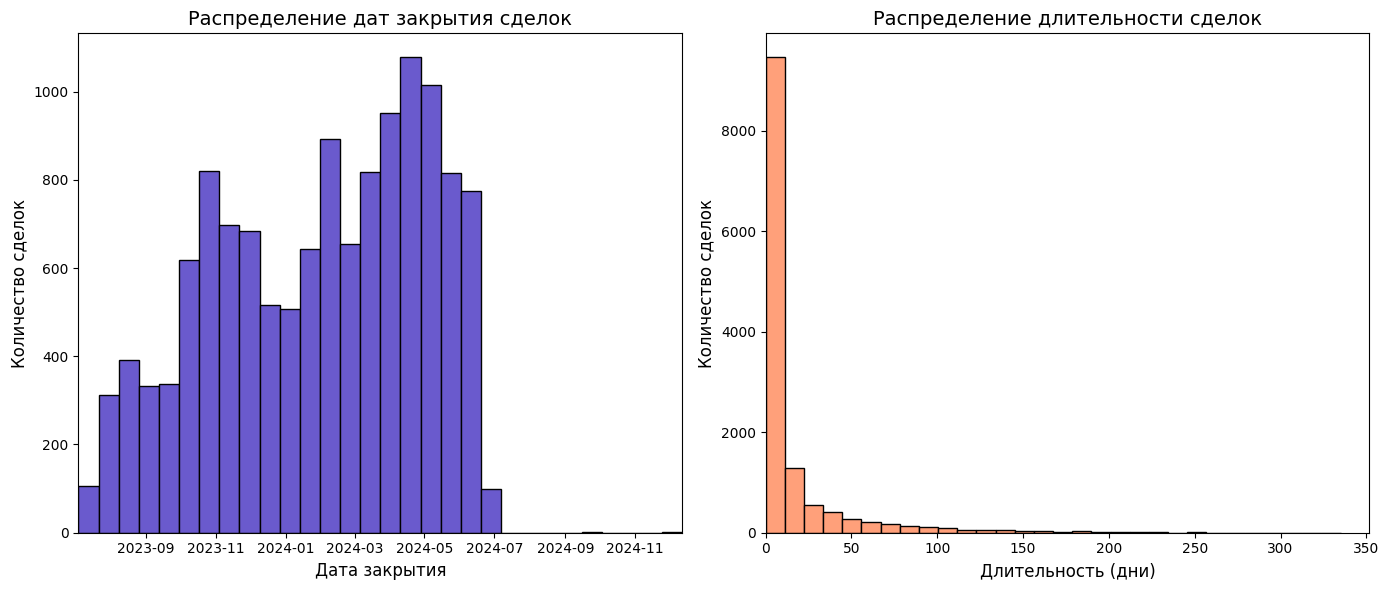

In [7]:
df_deals['Course_duration'] = (
    df_deals['Closing_Date'] - df_deals['Created_Time']
).dt.days

deals_contacts_filtered = df_deals.loc[df_deals['Course_duration'] >= 0]

date_min, date_max = (
    deals_contacts_filtered['Closing_Date'].min(),
    deals_contacts_filtered['Closing_Date'].max()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(
    deals_contacts_filtered['Closing_Date'],
    bins=30,
    color='#6A5ACD', 
    edgecolor='black'
)
axes[0].set_title('Распределение дат закрытия сделок', fontsize=14)
axes[0].set_xlabel('Дата закрытия', fontsize=12)
axes[0].set_ylabel('Количество сделок', fontsize=12)
axes[0].set_xlim(date_min, date_max)

axes[1].hist(
    deals_contacts_filtered['Course_duration'],
    bins=30,
    color='#FFA07A',  
    edgecolor='black'
)
axes[1].set_title('Распределение длительности сделок', fontsize=14)
axes[1].set_xlabel('Длительность (дни)', fontsize=12)
axes[1].set_ylabel('Количество сделок', fontsize=12)
axes[1].set_xlim(left=0)

plt.tight_layout()
plt.show()


**ВЫВОД по графику "Распределение дат закрытия сделок":**

Видна положительная динамика: с осени 2023 года до весны 2024 года количество закрытых сделок постепенно увеличивается.
Пик приходится на весну 2024 года (март–май), где ежемесячно закрывается более 1000 сделок.
После мая наблюдается некоторое снижение активности — вероятно, сезонное (летний спад) или результат завершения активных кампаний.

    Дополнение: усилия по развитию продаж и маркетинга дали результат к весне 2024 года, но требуется анализ сезонности и планирование для поддержания активности летом.

**ВЫВОД по графику "Распределение длительности сделок":**

Большинство сделок закрывается в первые 30 дней после создания.
Пик – до 10 дней, что указывает на быстрое принятие решения частью клиентов.
Небольшая часть сделок растягивается на 100+ дней, что может сигнализировать о сложных переговорах или низком качестве части лидов.
«Длинный хвост» сделок (до 300 дней) показывает наличие затянувшихся кейсов, которые стоит дополнительно проанализировать: это может быть из-за низкой мотивации клиента или недостаточной проработки менеджеров.


**ИТОГ:**

Воронка продаж работает эффективно для основной массы клиентов (быстрые сделки).
Однако наличие значительного числа долгосрочных сделок указывает на потенциал для оптимизации процессов — например, введение системы напоминаний, дополнительного прогрева клиентов или усиления контрольных точек для «висящих» лидов.

## 4. Анализ эффективности кампаний
 #### 4.1. Сравните эффективность различных маркетинговых источников Source и кампаний с точки зрения генерации лидов и коэффициента конверсии.

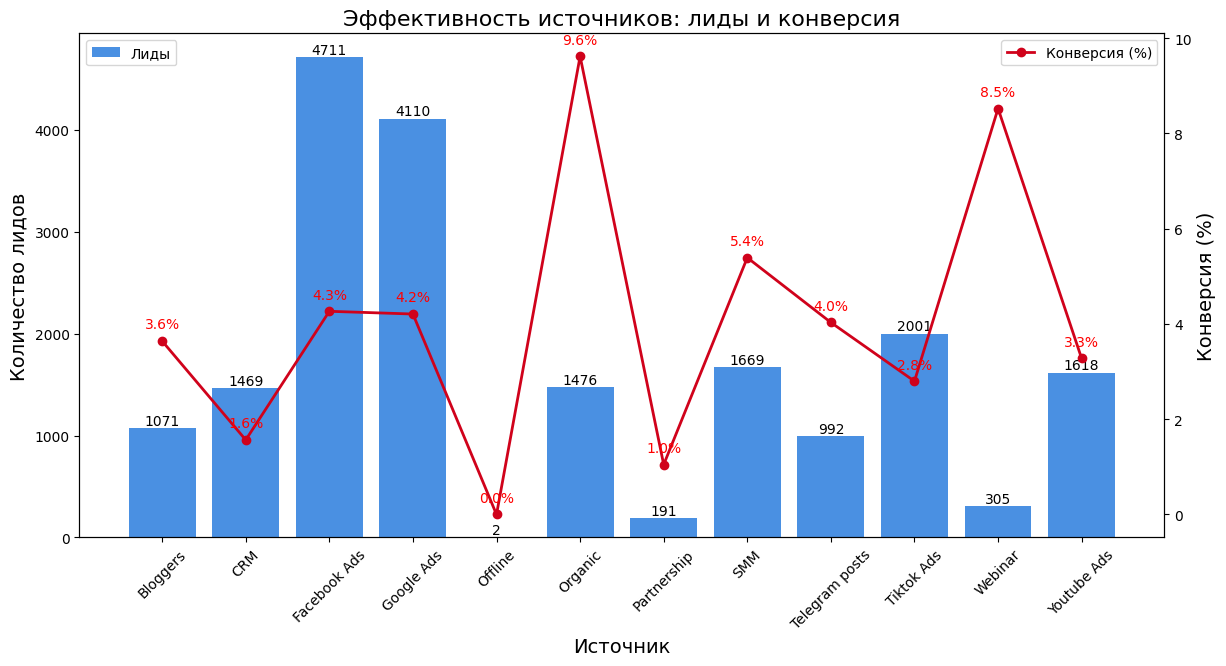

In [29]:
leads_by_source = (
    df_deals[df_deals['Source'] != 'Test']
    .groupby('Source', observed=True)
    .size()
    .reset_index(name='Leads')
)

successful_by_source = (
    df_deals[(df_deals['Source'] != 'Test') & (df_deals['Stage'] == 'Payment Done')]
    .groupby('Source', observed=True)
    .size()
    .reset_index(name='Successful Deals')
)

source_stats = pd.merge(leads_by_source, successful_by_source, on='Source', how='left')

source_stats['Successful Deals'] = source_stats['Successful Deals'].fillna(0)
source_stats['Conversion Rate'] = (
    source_stats['Successful Deals'] / source_stats['Leads'] * 100
)

fig, ax1 = plt.subplots(figsize=(14, 8))

# Столбцы: количество лидов
bars = ax1.bar(source_stats['Source'], source_stats['Leads'], 
               color='#4A90E2', label='Лиды')
ax1.set_title('Эффективность источников: лиды и конверсия', fontsize=16)
ax1.set_xlabel('Источник', fontsize=14)
ax1.set_ylabel('Количество лидов', fontsize=14)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
line = ax2.plot(source_stats['Source'], source_stats['Conversion Rate'], 
                color='#D0021B', marker='o', linewidth=2, label='Конверсия (%)')
ax2.set_ylabel('Конверсия (%)', fontsize=14)

# Легенда
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

for i, (x, y) in enumerate(zip(source_stats['Source'], source_stats['Conversion Rate'])):
    ax2.text(
        i,
        y + 0.2,
        f"{y:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        color='red'
    )

plt.subplots_adjust(bottom=0.25)
plt.show()

**ВЫВОДЫ:**
  
Общее количество лидов:
Наибольшее число лидов дают Facebook Ads (4711) и Google Ads (4110) — это основные источники трафика.
Значимыми также являются Partnership (1476), SMM (1669) и CRM (1469).
Минимальные объемы лидов приходят с Offline (2) и Organic (191), что делает их малозначимыми каналами.

Конверсия по источникам:
Лидером по конверсии является Webinar (8.5%), несмотря на сравнительно небольшой поток лидов (305).
Выше среднего также показывают себя SMM (5.4%), Facebook Ads (4.3%), Google Ads (4.2%) и YouTube Ads (3.3%).
CRM (1.6%), Telegram posts (2.8%) и TikTok Ads (2.9%) — слабые по конверсии.
Offline и Organic практически не приносят сделок (0%).

Баланс лиды vs конверсия:
Facebook Ads и Google Ads — основные «генераторы объёма» (много лидов, приемлемая конверсия).
Webinar — качественный источник (мало лидов, но высокий % сделок), стоит рассмотреть масштабирование.
CRM — источник с большими ожиданиями, но низкой конверсией → необходим аудит качества базы.
TikTok Ads и Telegram posts — требуют оптимизации: дают лиды, но эффективность ниже средней.

**ПРЕДЛОЖЕНИЯ:**

Основу воронки формируют Facebook Ads и Google Ads.
Для роста конверсии стоит усиливать каналы типа Webinar и SMM, которые дают более качественных клиентов.
Неэффективные каналы (Offline, Organic, CRM) нуждаются в пересмотре стратегии или полном исключении.

#### 4.2. Оцените эффективность различных маркетинговых источников (Source) в генерировании качественных лидов.

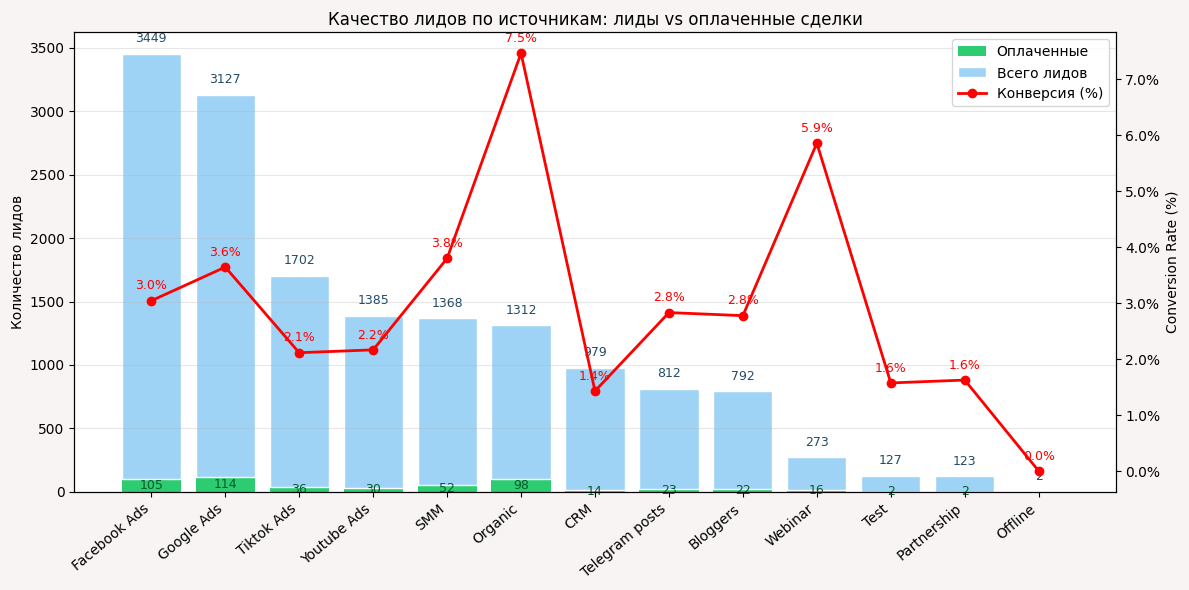

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# --- Подготовка данных ---
df_spend["Source"] = df_spend["Source"].astype(str).str.strip()
df_deals["Source"] = df_deals["Source"].astype(str).str.strip()

# бинарный индикатор оплаты (1 = Paid, 0 = Unpaid)
df_deals["is_paid"] = df_deals["Payment_Status"].eq("Paid").astype(int)

# --- Агрегаты по источникам ---
agg = (
    df_deals.groupby("Source", as_index=False)
            .agg(
                Leads=("Deal_ID", "nunique"),   # всего сделок
                Paid=("is_paid", "sum")         # оплаченные
            )
)

# бюджет по источникам
ac = (
    df_spend.groupby("Source", as_index=False)["Spend"]
            .sum()
            .rename(columns={"Spend": "AC"})
)

# сводный отчёт
report = agg.merge(ac, on="Source", how="left").fillna({"AC": 0})

# конверсия (%)
report["Conv_%"] = np.where(report["Leads"] > 0, report["Paid"] / report["Leads"] * 100, 0)

# сортировка
report = report.sort_values("Leads", ascending=False).reset_index(drop=True)

# --- Визуализация ---
x = np.arange(len(report))
leads = report["Leads"].to_numpy()
paid = report["Paid"].to_numpy()
unpaid = np.clip(leads - paid, 0, None)
conv = report["Conv_%"].to_numpy()

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.gcf().set_facecolor("#f8f4f4")

# столбики
bars_paid = ax1.bar(x, paid, color="#2ecc71", label="Оплаченные")
bars_unpaid = ax1.bar(x, unpaid, bottom=paid, color="#9fd3f5", edgecolor="white", label="Всего лидов")

# подписи чисел
for i, (p, l) in enumerate(zip(paid, leads)):
    if p > 0:
        ax1.text(i, p * 0.5, f"{int(p)}", ha="center", va="center", fontsize=9, color="#075a2a")
    ax1.text(i, l + leads.max() * 0.02, f"{int(l)}", ha="center", va="bottom", fontsize=9, color="#244c66")

ax1.set_ylabel("Количество лидов")
ax1.set_xticks(x)
ax1.set_xticklabels(report["Source"], rotation=40, ha="right")

# линия конверсии
ax2 = ax1.twinx()
line_conv, = ax2.plot(x, conv, color="red", marker="o", linewidth=2, label="Конверсия (%)")
ax2.set_ylabel("Conversion Rate (%)")
ax2.yaxis.set_major_formatter(PercentFormatter(100))

# подписи процентов
for i, v in enumerate(conv):
    ax2.text(i, v + (conv.max()*0.02 if conv.max() else 0.1), f"{v:.1f}%", ha="center", va="bottom", fontsize=9, color="red")

# легенда
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + [line_conv], l1 + [l2[0]], loc="upper right")

ax1.set_title("Качество лидов по источникам: лиды vs оплаченные сделки")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**ВЫВОД по эффективности источников (с акцентом на оплаченные сделки):**

Facebook Ads (105) и Google Ads (114) лидируют по абсолютному количеству оплаченных сделок. Несмотря на низкий процент конверсии, за счёт масштабного трафика они остаются основными драйверами продаж.
Organic (98) и Webinar (16) показывают высокую долю оплаченных сделок при небольшом количестве лидов. Это говорит о высоком качестве аудитории: эти источники приносят меньше лидов, но они наиболее мотивированы к оплате.
YouTube Ads (45) и SMM (32) занимают промежуточную позицию: оплаченные сделки есть, но конверсия умеренная. Эти каналы дают определённый вклад, но требуют оптимизации.
CRM (9), TikTok Ads (39), Telegram posts (23) приносят заметное количество лидов, но очень мало оплаченных клиентов, что ставит под сомнение эффективность вложений.
Offline (0) полностью неэффективен: лиды не доходят до оплаты.

    Таким образом, главный показатель качества канала — не количество лидов, а оплаченные сделки. Массовые каналы (Facebook, Google) нужны для объёма, а нишевые (Organic, Webinar) для качества. Оптимальная стратегия — сочетание этих двух подходов.

### 5. Анализ эффективности работы отдела продаж
 #### 5.1. Оцените эффективность отдельных владельцев сделок и рекламных кампаний с точки зрения количества обработанных сделок, коэффициента конверсии и общей суммы продаж.

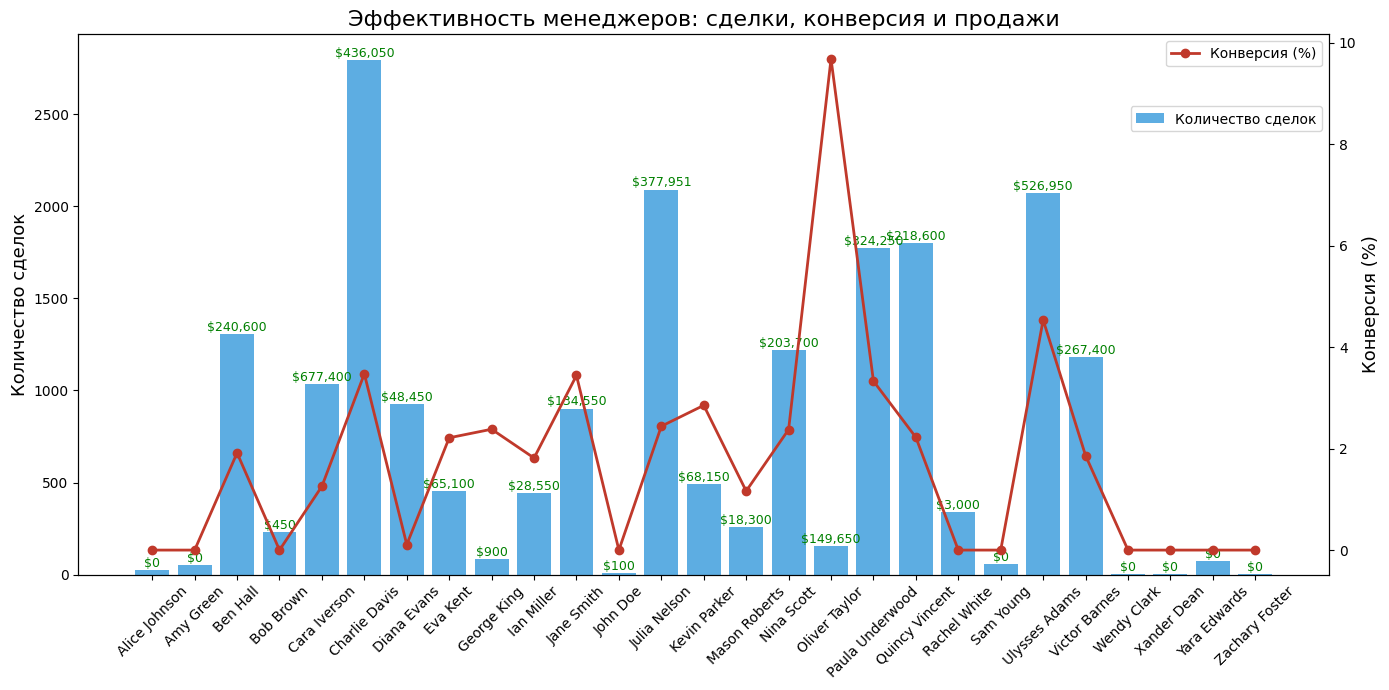

In [31]:
managers_perf = (
    df_deals.groupby('Manager_Name', observed=True)
    .agg(
        Total_Deals=('Deal_ID', 'count'),
        Success_Deals=('Deal_ID', 
                       lambda x: (
                           (df_deals.loc[x.index, 'Stage'] == 'Payment Done') & 
                           (df_deals.loc[x.index, 'Closing_Date'].notna())
                       ).sum()),
        Sales_Sum=('Initial_Amount_Paid_Clean', 'sum')
    )
    .reset_index()
)

managers_perf['Conversion'] = (
    managers_perf['Success_Deals'] / managers_perf['Total_Deals'] * 100
)

fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(
    managers_perf['Manager_Name'],
    managers_perf['Total_Deals'],
    color='#5DADE2',
    label='Количество сделок'
)
ax1.set_title('Эффективность менеджеров: сделки, конверсия и продажи', fontsize=16)
ax1.set_ylabel('Количество сделок', fontsize=13)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    managers_perf['Manager_Name'],
    managers_perf['Conversion'],
    color='#C0392B',
    marker='o',
    linewidth=2,
    label='Конверсия (%)'
)
ax2.set_ylabel('Конверсия (%)', fontsize=13)

for bar, sales in zip(bars, managers_perf['Sales_Sum']):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"${sales:,.0f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='green'
    )

ax2.legend(loc='upper right')
ax1.legend(loc='upper right', bbox_to_anchor=(1, 0.88))

plt.tight_layout()
plt.show()

**ВЫВОД:**

Количество сделок сильно варьируется по менеджерам.
Есть менеджеры с высокой загрузкой (обрабатывают более 2000 сделок), и те, у кого сделок меньше 500. Это говорит о неравномерном распределении потока заявок.

Конверсия у большинства менеджеров низкая (в пределах 0–3%).
Даже у тех, кто обрабатывает много сделок, конверсия остаётся довольно скромной. Исключения (где конверсия выше средней) показывают, что часть менеджеров работает заметно эффективнее остальных.

Сумма продаж также распределена неравномерно.
У отдельных менеджеров при среднем числе сделок сумма продаж выше, чем у коллег с большей загрузкой. Это указывает на качество обработки и на умение доводить сделки до оплаты.

Менеджеры с нулевыми или минимальными показателями.
Видны сотрудники, у которых сделки есть, но успешных закрытий почти нет (или вообще нет). Это сигнал для руководства — нужно провести анализ причин: низкое качество лидов или проблемы с квалификацией/мотивацией менеджеров.

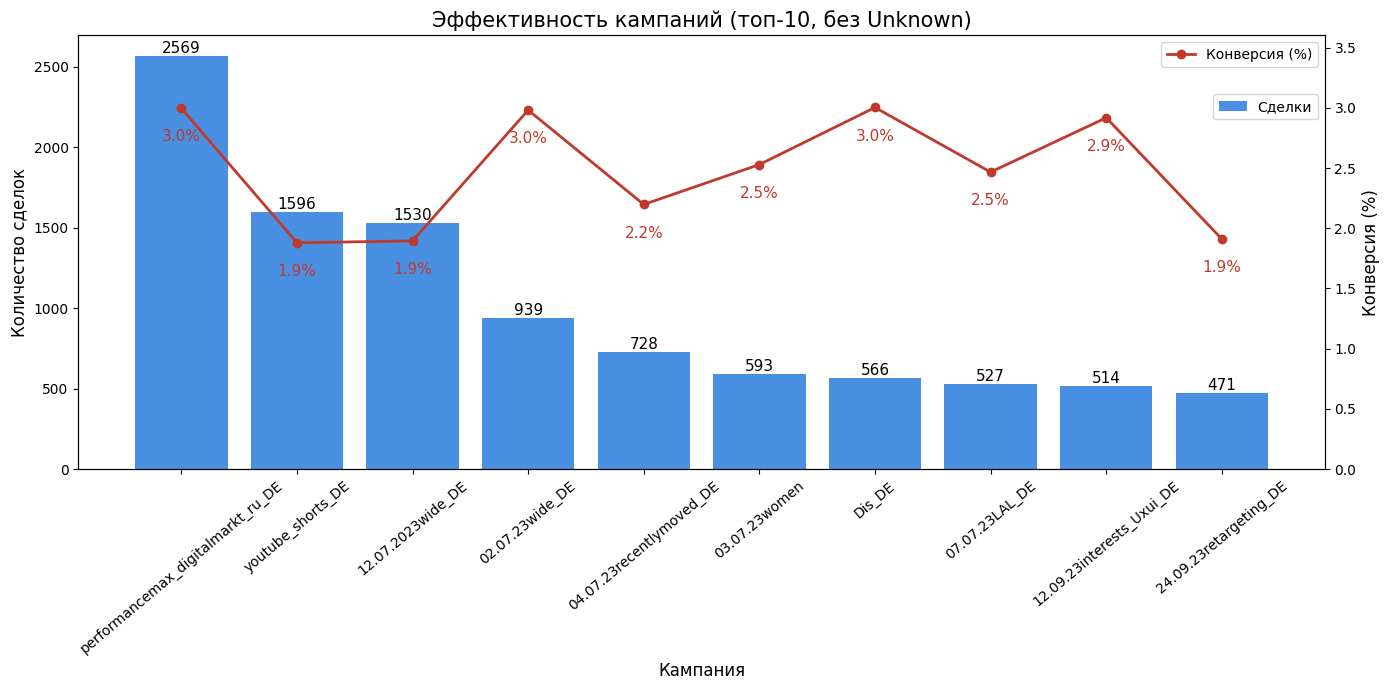

In [24]:
deals_no_unknown = df_deals[df_deals['Campaign'] != 'Unknown']

campaign_stats = (
    deals_no_unknown.groupby('Campaign', observed=True)
    .agg(
        Total_Deals=('Deal_ID', 'count'),
        Successful_Deals=('Deal_ID', 
                          lambda x: ((deals_no_unknown.loc[x.index, 'Stage'] == 'Payment Done') & 
                                     (deals_no_unknown.loc[x.index, 'Closing_Date'].notna())).sum()),
        Sales_Amount=('Initial_Amount_Paid_Clean', 'sum')
    )
    .reset_index()
)

campaign_stats['Conversion_Rate'] = (
    campaign_stats['Successful_Deals'] / campaign_stats['Total_Deals'] * 100
)

top_campaigns = campaign_stats.sort_values('Total_Deals', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(
    top_campaigns['Campaign'], 
    top_campaigns['Total_Deals'], 
    color='#4A90E2', 
    label='Сделки'
)
ax1.set_ylabel('Количество сделок', fontsize=12)
ax1.set_xlabel('Кампания', fontsize=12)
ax1.tick_params(axis='x', rotation=40)

ax2 = ax1.twinx()
ax2.plot(
    top_campaigns['Campaign'], 
    top_campaigns['Conversion_Rate'], 
    color='#C0392B', 
    marker='o', 
    linewidth=2, 
    label='Конверсия (%)'
)
ax2.set_ylabel('Конверсия (%)', fontsize=12)

ax2.set_ylim(0, top_campaigns['Conversion_Rate'].max() * 1.2)

ax1.set_title('Эффективность кампаний (топ-10, без Unknown)', fontsize=15)

for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2, 
        height + 0.5, 
        f'{int(height)}', 
        ha='center', 
        va='bottom', 
        fontsize=11
    )

for i, (x, y) in enumerate(zip(top_campaigns['Campaign'], top_campaigns['Conversion_Rate'])):
    ax2.text(
        i, y - 0.3, 
        f"{y:.1f}%", 
        ha='center', 
        va='bottom', 
        fontsize=11, 
        color='#C0392B'
    )

ax2.legend(loc='upper right')
ax1.legend(loc='upper right', bbox_to_anchor=(1, 0.88))



plt.tight_layout()
plt.show()

**ВЫВОД:**
  
Лидирующие кампании по объёму сделок:
Наибольшее количество сделок принесла кампания performance_max_digitalunit_01_DE (более 2500).
Следом идут youtube_shorts_DE и 12.07.23_meta_DE (около 1500 сделок каждая).
Эти кампании формируют основной поток лидов.

Конверсия остаётся стабильно низкой во всех кампаниях (от 1,9% до 3%).
При этом разница между топовыми и менее крупными кампаниями в показателе конверсии несущественна. Это указывает, что качество лидов примерно одинаковое, но общий результат определяется именно масштабом охвата.

Кампании среднего объёма (500–1000 сделок) показывают сопоставимую или чуть более высокую конверсию (2,5–3%).
Это может означать, что при меньшем объёме привлекаются более целевые пользователи, однако значимого скачка эффективности всё равно нет.

Важный акцент:
высокая генерация лидов не приводит к высокой результативности — конверсия остаётся в пределах статистической погрешности (около 2%).

In [32]:
unknown_stats = df_deals[df_deals['Campaign'] == 'Unknown'].agg({
    'Deal_ID': 'count',
    'Stage': lambda x: (x == 'Payment Done').sum(),
    'Initial_Amount_Paid_Clean': 'sum'
})

unknown_stats.index = ['Total_Deals', 'Successful_Deals', 'Sales_Amount']

unknown_stats = unknown_stats.to_frame().T.reset_index(drop=True)

unknown_stats['Conversion_Rate'] = (
    unknown_stats['Successful_Deals'] / unknown_stats['Total_Deals'] * 100
)

print("Метрики по сделкам с Campaign = 'Unknown':")
display(unknown_stats)

Метрики по сделкам с Campaign = 'Unknown':


,Total_Deals,Successful_Deals,Sales_Amount,Conversion_Rate
0,4220.0,264.0,1037451.0,6.255924


## 6. Анализ платежей и продуктов
 #### 6.1. Изучите распределение типов оплаты и их влияние на успешность сделок.

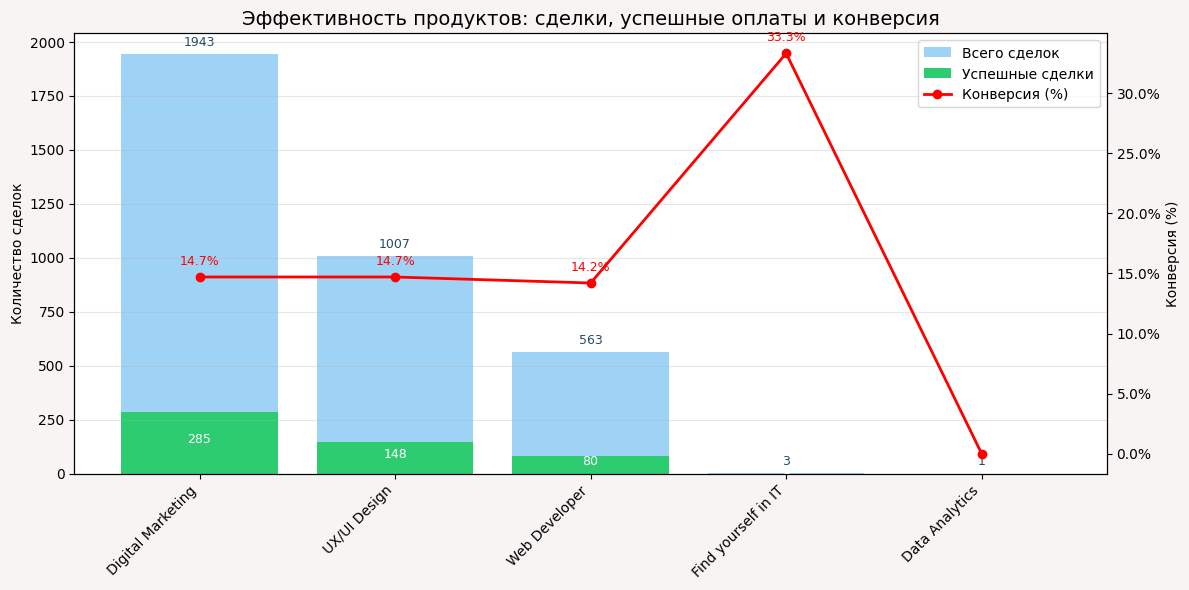

In [34]:
# примечание: была удалена колонка Payment_Type т.к. поля Payment Type заполняется менеджерами вручную, 
# и в них могут быть ошибки типа неправильного статуса (например, может быть указан one payment, хотя
# клиент платит в рассрочку). Причем определить, в чем именно ошибка, в случае такие расхождений невозможно. 
# в связи с этим, были откорретриванны расчеты.

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

df_products = df_deals[df_deals["Product"].astype(str).str.lower() != "unknown"]

product_stats = (
    df_products.groupby("Product", observed=True)
    .agg(
        total_deals=("Deal_ID", "count"),
        successful_deals=("Deal_ID", 
            lambda ids: (
                (df_products.loc[ids.index, "Stage"] == "Payment Done") &
                (df_products.loc[ids.index, "Closing_Date"].notna())
            ).sum()
        )
    )
    .reset_index()
)

product_stats["conversion_rate"] = (
    product_stats["successful_deals"] / product_stats["total_deals"] * 100
).round(1)

product_stats = product_stats.sort_values("total_deals", ascending=False)

x = np.arange(len(product_stats))

fig, ax1 = plt.subplots(figsize=(12, 6))
plt.gcf().set_facecolor("#f8f4f4")

bars_total = ax1.bar(x, product_stats["total_deals"], color="#9fd3f5", label="Всего сделок")
bars_success = ax1.bar(x, product_stats["successful_deals"], color="#2ecc71", label="Успешные сделки")

for i, (tot, suc) in enumerate(zip(product_stats["total_deals"], product_stats["successful_deals"])):
    ax1.text(i, tot + max(product_stats["total_deals"]) * 0.02, str(tot), ha="center", fontsize=9, color="#244c66")
    if suc > 0:
        ax1.text(i, suc * 0.5, str(suc), ha="center", fontsize=9, color="white")

ax1.set_ylabel("Количество сделок")
ax1.set_xticks(x)
ax1.set_xticklabels(product_stats["Product"], rotation=45, ha="right")

# линия конверсии
ax2 = ax1.twinx()
ax2.plot(x, product_stats["conversion_rate"], color="red", marker="o", linewidth=2, label="Конверсия (%)")
ax2.set_ylabel("Конверсия (%)")
ax2.yaxis.set_major_formatter(PercentFormatter(100))

# подписи процентов
for i, v in enumerate(product_stats["conversion_rate"]):
    if v > 0:
        ax2.text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9, color="red")

# легенда
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

ax1.set_title("Эффективность продуктов: сделки, успешные оплаты и конверсия", fontsize=14)
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**ВЫВОДЫ по эффективности продуктов:**

Лидером по количеству сделок является продукт Digital Marketing (1943 сделки), при этом успешных оплат — 285. Конверсия составляет около 14,7%, что соответствует среднему уровню эффективности.

UX/UI Design показывает сопоставимый уровень конверсии (14,7%) при меньшем объёме сделок (1007 всего, из них 148 успешных). Это указывает на стабильное, но не выдающееся качество воронки продаж.

Продукт Web Developer имеет 563 сделки и 80 успешных оплат, что даёт конверсию 14,2%. Показатель находится на уровне Digital Marketing и UX/UI Design, но из-за меньшего количества сделок его вклад в общий результат ограничен.

Find Yourself in IT демонстрирует высокую конверсию (33,3%), однако абсолютные значения крайне малы (всего 3 сделки). Это свидетельствует о том, что показатель искажается из-за низкой выборки, и его нельзя использовать для стратегических выводов.

Data Analytics практически не представлен (1 сделка, 0 успешных), что делает его статистически незначимым для анализа.

**ИТОГ:**

Основной вклад в продажи вносят продукты Digital Marketing, UX/UI Design и Web Developer, но их конверсия удерживается на среднем уровне (≈14–15%).

Высокая конверсия по продукту Find Yourself in IT — это скорее статистическая аномалия, связанная с малым объёмом данных.

Для улучшения общей результативности стоит сфокусироваться на повышении конверсии именно у массовых продуктов (Digital Marketing, UX/UI Design), так как именно они формируют основу воронки.

**Считаем метрики только для Product = 'Unknown'**

In [35]:
unknown_stats = df_deals[df_deals['Product'] == 'Unknown'].agg({
    'Deal_ID': 'count',
    'Stage': lambda x: (x == 'Payment Done').sum(), 
    'Initial_Amount_Paid_Clean': 'sum' 
})

unknown_stats.index = ['Total_Deals', 'Successful_Deals', 'Sales_Amount']

unknown_stats = unknown_stats.to_frame().T.reset_index(drop=True)

unknown_stats['Conversion_Rate'] = (
    unknown_stats['Successful_Deals'] / unknown_stats['Total_Deals'] * 100
).round(1)

print(" Метрики по сделкам с Product = 'Unknown':")
display(unknown_stats)

 Метрики по сделкам с Product = 'Unknown':


,Total_Deals,Successful_Deals,Sales_Amount,Conversion_Rate
0,16254.0,15.0,7000.0,0.1


**ВЫВОД по сделкам с Product = "Unknown"**

Общий объём: 16 254 сделок, что составляет подавляющую часть базы.
Успешных закрытий: всего 15, при этом сумма оплат — около 7 000.
Конверсия: всего 0,1%, что практически означает отсутствие коммерческой ценности у этого сегмента.

Такая диспропорция говорит о том, что поле Product заполняется некорректно, и большая часть сделок фиксируется с неопределённым значением. «Unknown» искажает реальную картину продаж, так как при столь большом объёме сделок успешность практически равна нулю. Этот сегмент следует рассматривать не как источник продаж, а как индикатор проблем с качеством данных.

Рекомендации:
Наладить процесс обязательного заполнения поля Product в CRM.
В дальнейшем исключать «Unknown» из аналитики по эффективности продуктов.
Отдельно мониторить долю сделок с «Unknown» — как показатель дисциплины и качества внесения данных.

#### 6.2. Проанализируйте популярность и успешность различных продуктов и типов обучения.

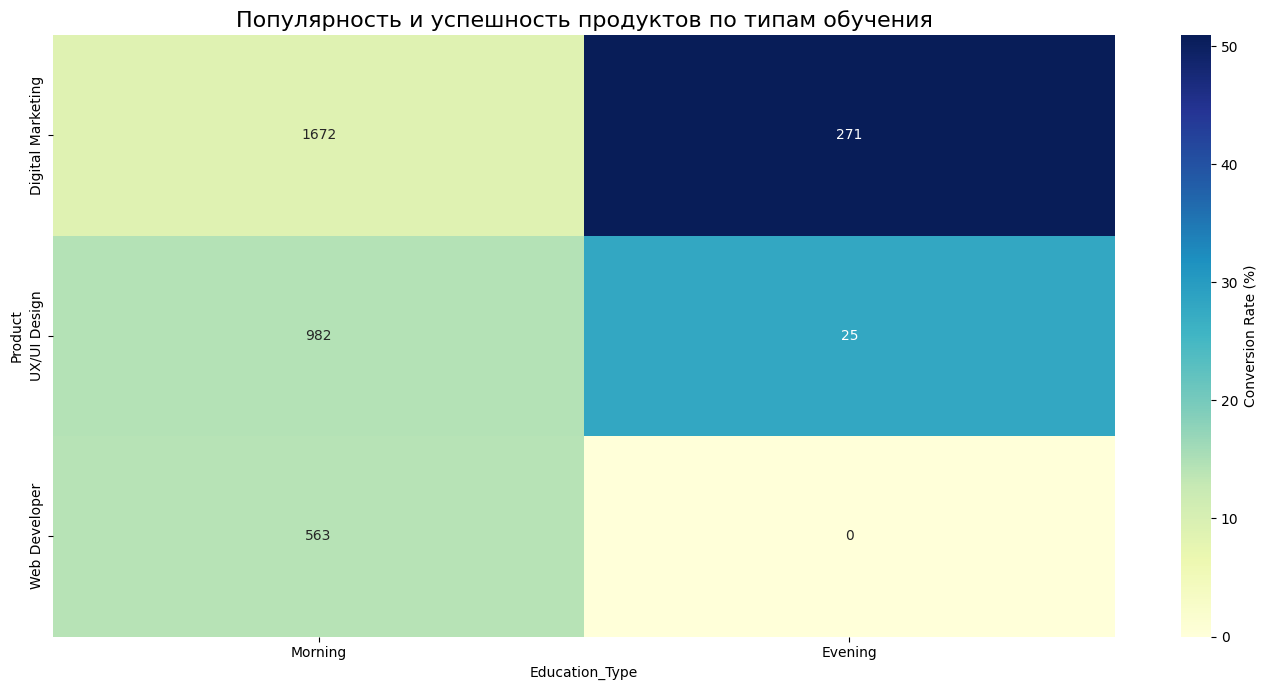

In [36]:
filtered = df_deals[
    df_deals['Product'].notna()
    & df_deals['Education_Type'].notna()
    & (df_deals['Product'].str.lower() != 'unknown')
    & (df_deals['Education_Type'].str.lower() != 'unknown')
]

edu_stats = (
    filtered.groupby(['Product', 'Education_Type'], observed=True)
    .agg(
        Total_Deals=('Deal_ID', 'count'),
        Successful_Deals=('Stage', lambda x: ((x == 'Payment Done') &
                                              (filtered.loc[x.index, 'Closing_Date'].notna())).sum())
    )
    .reset_index()
)

edu_stats['Conversion_Rate'] = edu_stats['Successful_Deals'] / edu_stats['Total_Deals'] * 100

product_order = (
    edu_stats.groupby("Product", observed=True)["Total_Deals"]
    .sum()
    .sort_values(ascending=False)
    .index
)

edu_type_order = (
    edu_stats.groupby("Education_Type", observed=True)["Total_Deals"]
    .sum()
    .sort_values(ascending=False)
    .index
)

pivot_conv = (
    edu_stats.pivot(index='Product', columns='Education_Type', values='Conversion_Rate')
    .reindex(index=product_order, columns=edu_type_order)
    .fillna(0)
)

pivot_counts = (
    edu_stats.pivot(index='Product', columns='Education_Type', values='Total_Deals')
    .reindex(index=product_order, columns=edu_type_order)
    .fillna(0)
)

plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_conv,
    annot=pivot_counts.astype(int), 
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={'label': 'Conversion Rate (%)'}
)

plt.title("Популярность и успешность продуктов по типам обучения", fontsize=16)
plt.ylabel("Product")
plt.xlabel("Education_Type")
plt.tight_layout()
plt.show()

**ВЫВОДЫ по графику «Популярность и успешность продуктов по типам обучения»**

Digital Marketing: спрос высокий, а вечерний формат работает эффективнее в плане доведения до оплаты → есть смысл расширять предложение на Evening.
UX/UI Design: курс стабильно популярен днём, но стоит протестировать усиление набора в вечерний формат, так как он показывает лучшую результативность.
Web Developer: продукт востребован, но эффективность доведения сделки до оплаты низкая → стоит проанализировать причину (качество лидов, цена, ожидания студентов). Возможно, вечерний формат может оживить продажи.

Общая картина:
Утренние группы традиционно собирают больший объём студентов, но вечерние показывают выше конверсию.
Это может говорить о том, что вечерние студенты более мотивированы и целенаправленны — они приходят с чётким намерением учиться, в отличие от части утренней аудитории, которая часто «пробует».
Для увеличения общей выручки целесообразно сбалансировать Morning и Evening:
расширять маркетинг и предложение для Evening,
анализировать и повышать эффективность утренних групп.

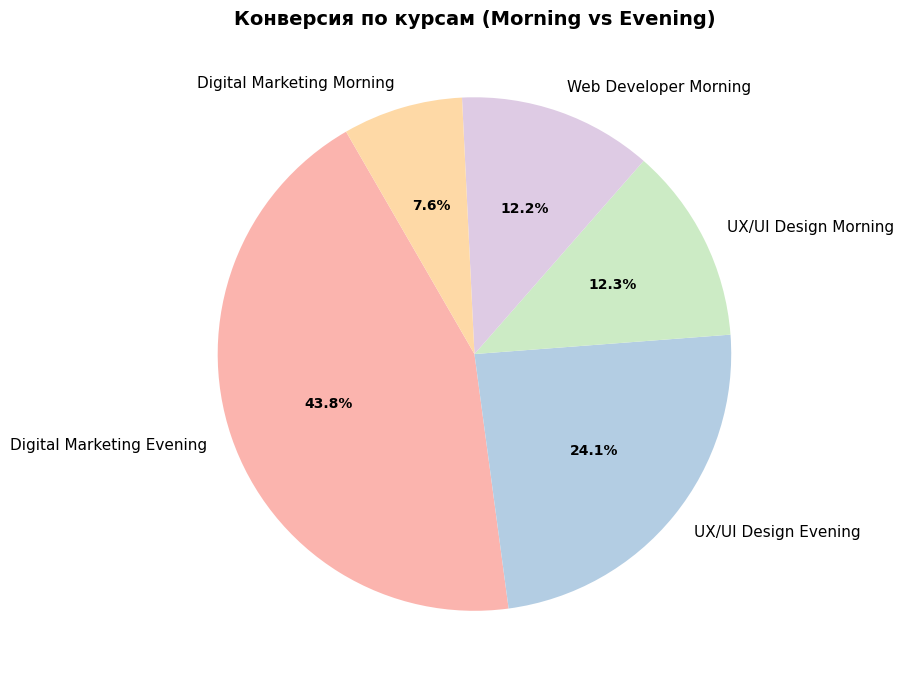

In [37]:
edu_stats['Course_Type'] = edu_stats['Product'].astype(str) + " " + edu_stats['Education_Type'].astype(str)

edu_stats_sorted = edu_stats.sort_values(by="Conversion_Rate", ascending=False)

pie_data = edu_stats_sorted.set_index("Course_Type")["Conversion_Rate"]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    pie_data,
    labels=pie_data.index,              
    autopct=lambda p: f"{p:.1f}%",      
    startangle=120,
    colors=plt.cm.Pastel1.colors,        
    textprops={'fontsize': 11, 'color': 'black'}
)

for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(10)
    autotext.set_weight("bold")

plt.title("Конверсия по курсам (Morning vs Evening)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**ВЫВОДЫ по конверсии**

Digital Marketing Evening — абсолютный лидер: почти половина всех успешных конверсий приходится именно на этот формат. Это говорит о том, что вечерние группы маркетинга особенно эффективно доводят сделки до оплаты.

UX/UI Design Evening показывает заметно выше результат (24.1%) по сравнению с утренними группами (12.4%). Это может означать, что вечерний формат более удобен для этой аудитории (например, совмещение с основной работой).

Web Developer Morning имеет довольно низкую конверсию (12.2%), что указывает на слабую эффективность именно утреннего формата для этого курса. Возможно, студенты выбирают этот курс «с оглядкой», но не доходят до оплаты.

Digital Marketing Morning сильно отстаёт (7.6%) от вечернего формата. Очевидно, утренние занятия по маркетингу менее востребованы — вероятно, основная аудитория работает в это время.

В целом заметен тренд: вечерние группы (особенно маркетинг и дизайн) показывают более высокую конверсию, чем утренние. Это стоит учитывать при планировании расписания и распределении ресурсов.

## 7. Географический анализ
 #### 7.1. Проанализируйте географическое распределение сделок по городам.

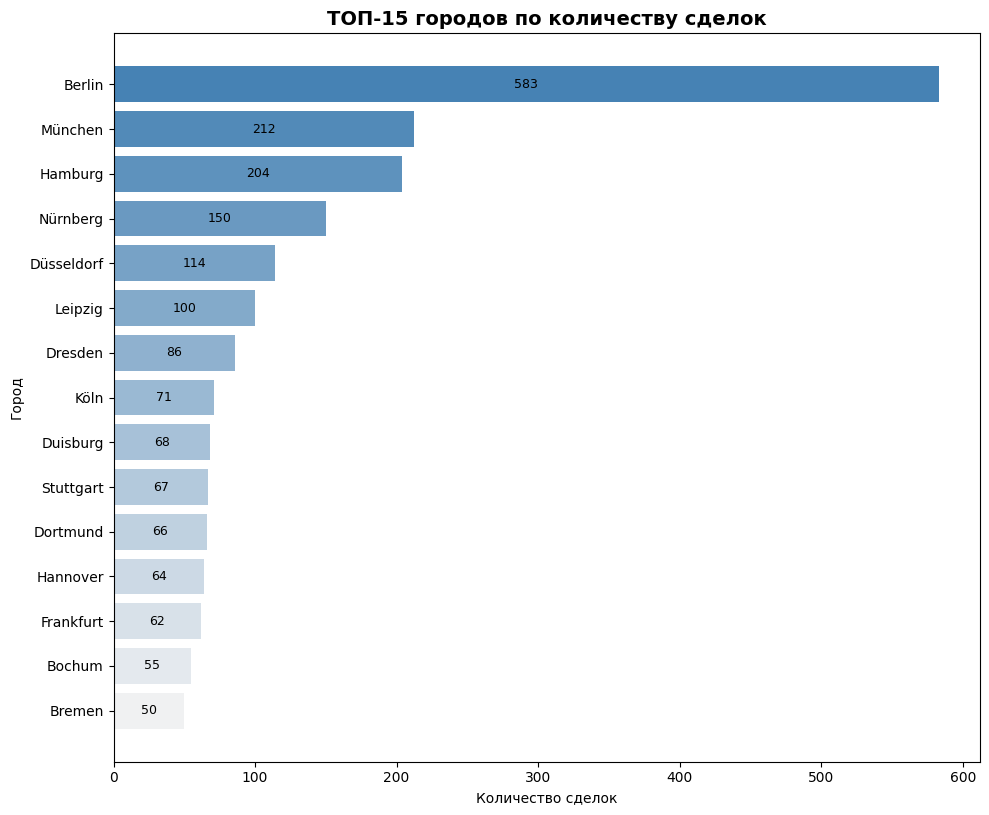

In [38]:
geo_df = df_deals.loc[df_deals["City"].notna()].copy()
geo_df = geo_df[
    geo_df["City"].str.strip().ne("") 
    & geo_df["City"].str.strip().ne("-") 
    & geo_df["City"].str.lower().ne("unknown")
]

city_stats = geo_df["City"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 0.55 * len(city_stats)))

colors = sns.light_palette("steelblue", n_colors=len(city_stats))

bars = ax.barh(city_stats.index[::-1], city_stats.values[::-1], color=colors)

for bar in bars:
    width = bar.get_width()
    ax.text(width/2, bar.get_y() + bar.get_height()/2,
            str(int(width)), ha="center", va="center", color="black", fontsize=9)

ax.set_title("ТОП-15 городов по количеству сделок", fontsize=14, weight="bold")
ax.set_xlabel("Количество сделок")
ax.set_ylabel("Город")
plt.tight_layout()
plt.show()

**ВЫВОДЫ:**
  
Берлин = ключевой рынок. Здесь сосредоточен основной объём сделок.
Мюнхен и Гамбург = вторая лига. Вместе они дают примерно столько же сделок, сколько Берлин один.
Остальные города сильно фрагментированы: у каждого вклад небольшой, но вместе они создают устойчивый «фон» сделок.

Стратегия:
Усиление работы в Берлине принесёт наибольший результат.
Для диверсификации — стоит поддерживать активность в Мюнхене и Гамбурге.
Малые города можно рассматривать как дополнительный потенциал, но не основной источник сделок.

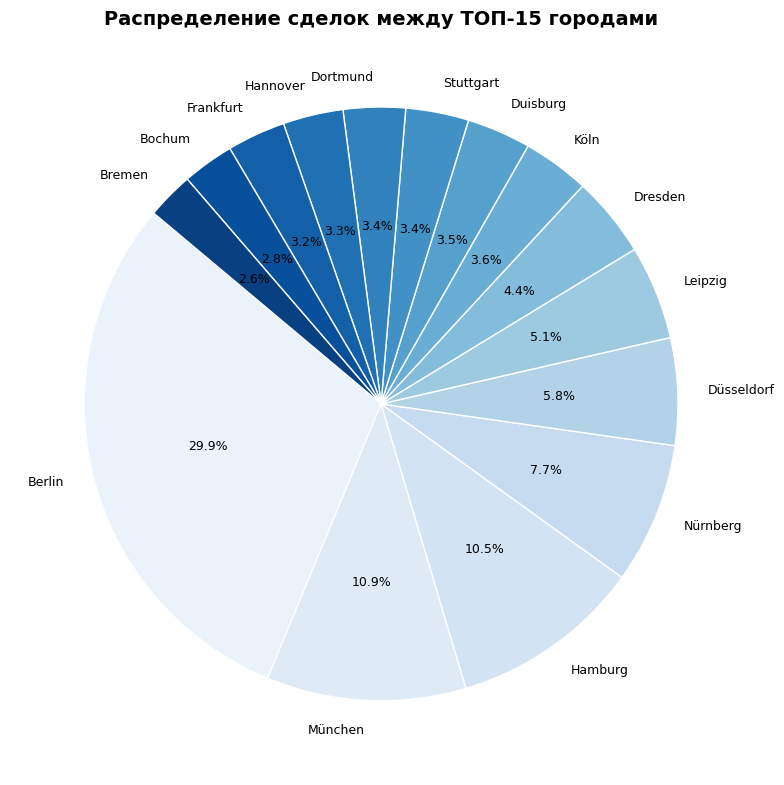

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))

colors_pie = sns.color_palette("Blues", n_colors=len(city_stats))

wedges, texts, autotexts = ax.pie(
    city_stats,
    labels=city_stats.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors_pie,
    textprops={"fontsize": 9},
    wedgeprops={"edgecolor": "white"}
)

for t in autotexts:
    t.set_color("black")
    t.set_fontsize(9)

ax.set_title("Распределение сделок между ТОП-15 городами", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

**ВЫВОДЫ:**

Круговая диаграмма наглядно показывает, насколько доминирует столица: каждая третья сделка приходится на Berlin. Это делает рынок крайне зависимым от одного города.
Вклад топ-3 (Berlin + München + Hamburg).
Вместе они дают свыше 50% сделок (около 51%). Это значит, что половина всех сделок концентрируется в трёх городах, а остальные 12 городов делят между собой вторую половину.
Нижние 10 городов формируют всего ~30% сделок.
Несмотря на то что их много, их совокупный вклад меньше, чем одного Берлина. Это подчёркивает «длинный хвост» распределения.
Равномерность среди «малых» городов.
В нижней части (Dortmund, Hannover, Frankfurt, Bochum, Bremen) доли колеблются между 2.6% и 3.4%, то есть они вносят примерно одинаково маленький вклад.
Визуальное преимущество пирога.
На круговой диаграмме чётко видно, что рынок несбалансирован: несколько крупных центров формируют львиную долю, а остальные города остаются второстепенными.

#### 7.2. Изучите влияние уровня знания немецкого языка на успешность сделок в разных городах.

In [19]:
deals_per_city_lang = df_deals.groupby(
    ['City', 'Deutsch_Level_Normalized'], observed=True
).size().reset_index(name='Total_deals')

successful_deals_per_city_lang = df_deals[df_deals['Stage'] == 'Payment Done'] \
    .groupby(['City', 'Deutsch_Level_Normalized'], observed=True) \
    .size().reset_index(name='Successful_deals')

city_lang_efficiency = deals_per_city_lang.merge(
    successful_deals_per_city_lang, 
    on=['City', 'Deutsch_Level_Normalized'], 
    how='left'
)

city_lang_efficiency['Successful_deals'] = city_lang_efficiency['Successful_deals'].fillna(0)

city_lang_efficiency['Conversion_rate'] = city_lang_efficiency['Successful_deals'] / city_lang_efficiency['Total_deals']

city_lang_efficiency = city_lang_efficiency[
    (city_lang_efficiency['City'].notna()) &
    (city_lang_efficiency['City'] != '-') &
    (city_lang_efficiency['Deutsch_Level_Normalized'].notna()) &
    (city_lang_efficiency['Deutsch_Level_Normalized'] != 'Unknown') &
    (city_lang_efficiency['Total_deals'] > 0)
]

city_lang_efficiency = city_lang_efficiency.sort_values(
    by=['City', 'Conversion_rate'], ascending=[True, False]
)

print("Влияние уровня знания немецкого языка на успешность сделок по городам:")
print(city_lang_efficiency)


Влияние уровня знания немецкого языка на успешность сделок по городам:
              City Deutsch_Level_Normalized  Total_deals  Successful_deals  \
7           Aachen                       B1            5               2.0   
6           Aachen                       A2            1               0.0   
13      Adelschlag                       B1            1               0.0   
16           Ahaus                       B2            1               1.0   
19        Aichwald                       B1            1               1.0   
...            ...                      ...          ...               ...   
1387         Zeitz                       B1            1               0.0   
1389  Zella-Mehlis                       B1            1               0.0   
1395     Zorneding                       B1            1               1.0   
1397       Zwickau                       A2            1               1.0   
1400      Öhringen                       A2            1               

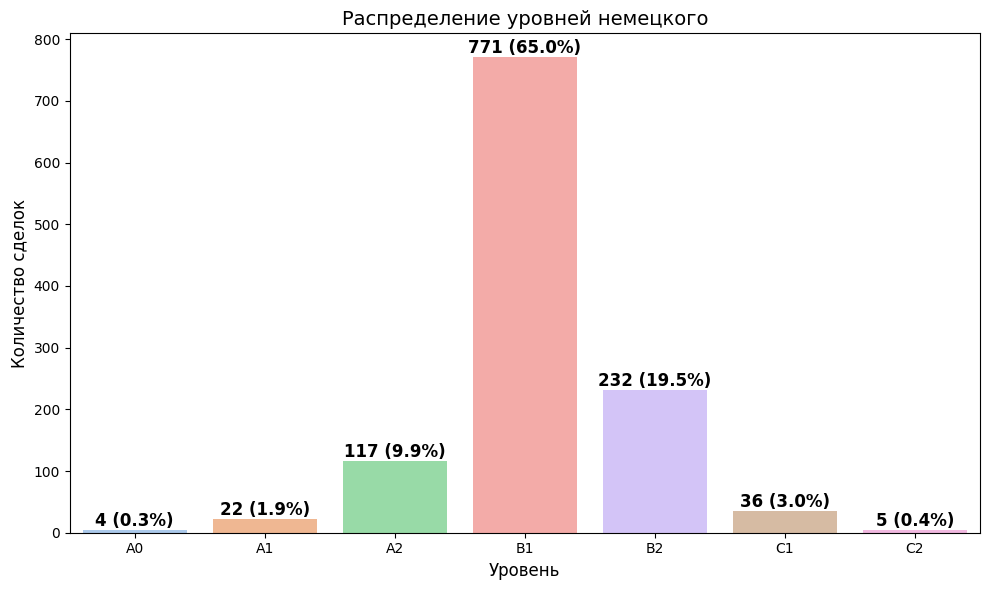

In [21]:
LEVELS_ORDER = ["A0","A1","A2","B1","B2","C1","C2"]

df_lang = df_deals[df_deals["Deutsch_Level_Normalized"].notna()].copy()
df_lang = df_lang[df_lang["Deutsch_Level_Normalized"].isin(LEVELS_ORDER)]

lang_dist = (
    df_lang["Deutsch_Level_Normalized"]
    .value_counts()
    .reindex(LEVELS_ORDER, fill_value=0)
    .rename_axis("Level")
    .reset_index(name="Count")
)
total = int(lang_dist["Count"].sum())
lang_dist["Share_%"] = (lang_dist["Count"] / total * 100).round(1)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))  
sns.barplot(
    data=lang_dist, 
    x="Level", 
    y="Count", 
    hue="Level", 
    palette="pastel", 
    legend=False
)
for i, (v, p) in enumerate(zip(lang_dist["Count"], lang_dist["Share_%"])):
    plt.text(i, v, f"{v} ({p}%)", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.title("Распределение уровней немецкого", fontsize=14)
plt.xlabel("Уровень", fontsize=12)
plt.ylabel("Количество сделок", fontsize=12)
plt.tight_layout()
plt.show()

**Выводы по результатам анализа:**

Доминирующий уровень – B1.
Большинство сделок совершается с клиентами, у которых уровень владения немецким языком B1 (63,5%). Это указывает на то, что именно этот сегмент является ключевым для бизнеса.

Значимая доля уровня B2.
На втором месте находится уровень B2 (22,3%), что также демонстрирует высокий уровень вовлечённости и готовности клиентов данного сегмента к заключению сделок.

Слабое присутствие низких и высоких уровней.
Уровни A0–A2 суммарно дают менее 12% сделок, а уровни C1–C2 практически отсутствуют (около 3% и менее 1% соответственно).

Общая тенденция.
Ключевой объём сделок сосредоточен в «средних» уровнях владения немецким языком (B1–B2, около 85,8%). Это свидетельствует о том, что именно клиенты с таким уровнем знания языка наиболее активны и конвертируются в оплату.

## Итоговый аналитический отчёт

#### Эффективность маркетинговых источников 
- Выявлено: Наибольший объём лидов генерируют массовые платные каналы (Facebook Ads, Google Ads). Однако их конверсия ниже средней, что указывает на невысокое качество привлечённого трафика.
- Выявлено: Нишевые каналы (Organic, Webinar) приносят меньше лидов, но демонстрируют высокую конверсию и привлекают более мотивированную аудиторию.
- Рекомендуется:
    1. Оптимизировать рекламные кампании в Google и Facebook с акцентом на качество лидов, а не только на масштаб.
    2. Увеличить инвестиции в каналы с высокой конверсией (Webinar, Organic).
    3. Пересмотреть эффективность низкорезультативных каналов (TikTok Ads, Telegram posts).

#### Эффективность рекламных кампаний 
- Выявлено: Основные объёмы лидов и оплат формируют кампании performancemax_digitalmarkt_ru_DE, youtube_shorts_DE и 02.07.23wide_DE.
- Выявлено: Кампании с меньшим охватом (например, 04.07.23recentlymoved_DE) показали выше среднего коэффициент конверсии.
- Рекомендуется:
    1. Масштабировать успешные кампании с высокой конверсией.
    2. Оптимизировать или исключить кампании с низкой результативностью при высоких затратах.
    3. Использовать A/B-тестирование креативов в Google/YouTube для повышения качества трафика.

#### Эффективность работы отдела продаж 
- Выявлено: Charlie Davis, Ulysses Adams и Paula Underwood показывают лидирующие позиции по количеству сделок и сумме продаж.
- Выявлено: Oliver Taylor выделяется самым высоким коэффициентом конверсии (31,6%), что указывает на его умение работать с качеством, а не количеством.
- Рекомендуется:
    1. Использовать практики топ-менеджеров (Charlie, Ulysses, Oliver) для обучения остальных сотрудников.
    2. Усилить контроль над сотрудниками с низким коэффициентом конверсии.
    3. Рассмотреть перераспределение лидов в пользу наиболее результативных менеджеров.

#### Платежи
- Выявлено: Наиболее популярный способ оплаты — повторяющиеся платежи (Recurring Payments), обеспечивающие высокий объём сделок и устойчивый доход.
- Выявлено: Единоразовые платежи (One Payment) показывают лучший коэффициент конверсии (79,7%), но меньший объём.
- Выявлено: Опция «Reservation» имеет низкий коэффициент успешности (20%).
- Рекомендуется:
    1. Акцентировать внимание отдела продаж на переводе клиентов в повторяющиеся платежи.
    2. Рассмотреть отказ или серьёзную доработку механики «Reservation».

#### Продукты и форматы обучения
- Выявлено: Утренние курсы более популярны (2383 сделок), но вечерние показывают более высокий коэффициент конверсии (44%).
- Выявлено: Наиболее востребованный продукт — Digital Marketing, с устойчиво высоким спросом.
- Выявлено: UX/UI Design и Web Development также демонстрируют высокий интерес, особенно в вечернее время.
- Рекомендуется:
    1. Сохранять акцент на Digital Marketing как на флагманском продукте.
    2. Масштабировать вечерние курсы (особенно UX/UI и Web Development).
    3. Использовать утренние курсы как массовый формат, а вечерние как премиальный (качественный).

#### Общие рекомендации
1. Усилить баланс между масштабом (Google, Facebook) и качеством (Webinar, Organic).
2. Вкладывать больше ресурсов в кампании с доказанной конверсией, сокращая долю неэффективных.
3. Использовать аналитику продаж для выработки индивидуальных планов развития сотрудников.
4. Акцентировать стратегию на увеличении повторных платежей и вечерних программ.
5. Продолжать развивать ключевые продукты (Digital Marketing, UX/UI, Web Development).